In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from picoscenes import Picoscenes
from pathlib import Path
from picoparser import PicoParser

In [ ]:
filename = "1/rx_2_260413_161147"
csi_path = Path(f"/home/drone/BTP/alone/{filename}.csi")

In [13]:
def extract_csi_parallely(
    csi_path: Path,
    ts_start: int,
    ts_end: int,
    tx_idx: int   = 0,
    rx_idx: int   = 0,
    csi_idx: int  = 0,
    min_len: int  = 998,
    num_workers: int = 4,
) -> tuple[np.ndarray, np.ndarray]:
    """Parse a .csi file and return (ts_arr [ns, int64], csi_arr [complex64])."""
    with PicoParser(csi_path, num_workers) as parser:
        i = 0
        ts_list, csi_list = [], []

        for fr in parser.getFrames():
            try:
                ts  = fr.rxSBasic.systemTime
                csi = fr.csi.csi
                csi = np.array([sub_csi[tx_idx][rx_idx][csi_idx] for sub_csi in csi])
            except Exception:
                continue

            if ts is None:
                continue
            if (int(ts) < int(ts_start)):
                continue
            if (int(ts) > int(ts_end)):
                break
            if csi.ndim == 0:
                continue
            if csi.shape[0] < min_len:
                continue

            ts_list.append(int(ts))
            csi_list.append(csi[:min_len])

            if (i + 1) % 1000 == 0:
                print(f"    ...parsed {i + 1} frames")
            i += 1

        print(f"    {i} frames parsed in total")
        return np.array(ts_list, dtype=np.int64), np.array(csi_list)

In [15]:
ts_arr, csi_arr = extract_csi_parallely(csi_path, 1775890745198000000, 1775890805481000000, num_workers=4)

    ...parsed 1000 frames
    ...parsed 2000 frames
    ...parsed 3000 frames
    ...parsed 4000 frames
    ...parsed 5000 frames
    ...parsed 6000 frames
    ...parsed 7000 frames
    ...parsed 8000 frames
    ...parsed 9000 frames
    ...parsed 10000 frames
    ...parsed 11000 frames
    ...parsed 12000 frames
    ...parsed 13000 frames
    ...parsed 14000 frames
    ...parsed 15000 frames
    ...parsed 16000 frames
    ...parsed 17000 frames
    ...parsed 18000 frames
    ...parsed 19000 frames
    ...parsed 20000 frames
    ...parsed 21000 frames
    ...parsed 22000 frames
    ...parsed 23000 frames
    ...parsed 24000 frames
    ...parsed 25000 frames
    ...parsed 26000 frames
    ...parsed 27000 frames
    ...parsed 28000 frames
    ...parsed 29000 frames
    29478 frames parsed in total


In [16]:
print(f"CSI array dtype: {csi_arr.dtype}, Timestamps array dtype: {ts_arr.dtype}")

print(f"CSI array shape: {csi_arr.shape}")
print(f"Timestamps array shape: {ts_arr.shape}")

# Data Frequency
time_diffs = np.diff(ts_arr) / 1e9  # Convert ns to seconds
total_time = (ts_arr[-1] - ts_arr[0]) / 1e9
print(f"Total time span: {total_time:.3f} seconds")
print(f"Average time between frames: {np.mean(time_diffs):.3f} seconds")
print(f"Frequency: {len(ts_arr)/total_time:.3f} Hz")

CSI array dtype: complex64, Timestamps array dtype: int64
CSI array shape: (29478, 998)
Timestamps array shape: (29478,)
Total time span: 60.280 seconds
Average time between frames: 0.002 seconds
Frequency: 489.018 Hz


In [17]:
# create pandas dataframe
df = pd.DataFrame(csi_arr, columns=range(1, csi_arr.shape[1] + 1))
df.insert(0, 'timestamp', ts_arr)
csv_path = Path(f"data_csv/{filename}.csv")
print("DataFrame created.")

display(df)

# dump as csv
want_to_store_csv = 0

if want_to_store_csv:
    df.to_csv(csv_path, index=False)
    print(f"Data saved to {csv_path}")

DataFrame created.


,timestamp,1,2,3,4,5,6,7,8,9,...,989,990,991,992,993,994,995,996,997,998
0,1775890745199400899,16.999884+90.000023j,60.999886+ 84.000084j,96.999924+ 52.000137j,114.999985+ 16.000050j,114.000008- 29.999981j,92.000038- 65.999954j,66.000153- 93.999901j,35.000034-103.999992j,-1.074539-103.310211j,...,13.817591+47.718700j,28.194347+44.351761j,39.347424+34.709938j,48.421932+17.897375j,52.972095+ 1.719496j,46.302685-18.386435j,36.641232-29.638157j,21.809725-39.004307j,-1.345471-39.385143j,-16.440842-31.395834j
1,1775890745201370674,0.000006-93.000000j,-44.999886- 96.000053j,-81.999969- 69.000031j,-110.000000- 39.000019j,-120.999992+ 3.999949j,-105.000008+ 40.999992j,-87.999969+ 71.000046j,-60.000015+ 92.999992j,-26.538399+ 99.782181j,...,-17.978712-46.890999j,-32.903160-42.395535j,-41.849415-29.165499j,-46.855953-15.149896j,-51.309155- 0.608286j,-45.516983+17.210575j,-37.472698+29.082588j,-21.219147+36.847626j,0.234336+41.048084j,14.284194+30.805225j
2,1775890745203275037,67.999901+63.000103j,98.999992+ 30.999994j,107.000008- 12.999952j,102.000053- 56.999908j,77.000000- 92.000000j,39.000134-105.999947j,1.000028-114.000000j,-30.999866-106.000031j,-58.746826- 84.675163j,...,-46.063347+22.139746j,-39.848763+35.455265j,-28.613829+44.623413j,-12.213084+51.369644j,5.215715+51.592606j,20.938549+43.755886j,34.634499+32.763565j,41.166275+17.301386j,39.664814- 3.564055j,29.239134-17.031523j
3,1775890745205329122,4.999861+91.000008j,45.999889+ 94.000046j,84.999969+ 69.000046j,108.999939+ 38.000175j,120.000000- 4.999984j,106.000053- 39.999844j,90.000076- 70.999901j,64.000076- 89.999947j,32.979229- 97.327950j,...,31.104361-39.351223j,17.897190-48.422001j,6.152610-48.807228j,-9.754670-49.039234j,-23.247297-48.005863j,-36.246479-33.573689j,-43.799587-20.846970j,-42.748375- 4.751474j,-38.013180+15.491873j,-24.540991+25.273300j
4,1775890745207314638,-88.999992-28.000021j,-101.000008+ 13.999976j,-93.000000+ 54.000000j,-73.000153+ 89.999870j,-38.000160+111.999939j,0.999884+110.999992j,33.999905+107.000038j,62.999973+ 91.000023j,82.295158+ 64.118523j,...,-49.075615-14.750747j,-53.341919- 1.624533j,-47.438995+11.599197j,-42.585224+26.823465j,-38.035748+37.125214j,-18.482416+45.479671j,-4.210162+47.699833j,14.663869+42.964764j,27.703133+30.537460j,32.344608+13.958013j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29473,1775890805471328573,37.000034+62.999985j,66.999924+ 42.000130j,85.999992+ 9.000057j,83.000046- 32.999901j,66.000053- 64.999947j,33.000156- 81.999939j,2.000149- 86.999992j,-27.999876- 78.000046j,-49.704044- 61.745483j,...,-57.393982-16.701210j,-56.685116+ 7.197034j,-48.565231+27.684259j,-37.111935+44.087456j,-16.973200+52.401432j,4.455115+53.152157j,23.530737+42.181808j,39.199429+22.790459j,41.599884+ 2.539608j,29.629307-15.069974j
29474,1775890805473366428,-32.000023+63.999992j,0.999954+ 80.000000j,40.000027+ 78.999985j,70.999962+ 53.000034j,89.999992+ 19.000065j,86.000023- 14.999913j,74.000031- 46.999950j,50.000118- 63.999901j,27.027193- 75.823112j,...,-10.756349-57.700092j,-27.798830-47.489204j,-41.290058-33.602543j,-55.287540-16.531410j,-55.198112+ 5.212347j,-45.917778+25.447147j,-26.943207+38.523544j,-4.951580+46.866642j,13.549430+39.120495j,26.844889+22.189009j
29475,1775890805475231889,-72.000084+31.999811j,-54.000179+ 63.999847j,-23.000246+ 87.999931j,20.000055+ 92.999985j,55.999977+ 81.000008j,78.999901+ 52.000145j,92.999985+ 22.000067j,87.000031- 12.999800j,76.775368- 36.582088j,...,25.741621+49.672619j,39.383865+33.969265j,48.240307+17.800930j,54.718220- 1.707754j,46.891022-17.978653j,35.535301-36.636627j,17.517431-42.416267j,-5.836557-44.720627j,-21.043814-33.304024j,-30.578117-15.329013j
29476,1775890805477544040,74.000046-21.999851j,63.000069- 55.999935j,36.000088- 87.999962j,-5.999932- 95.000008j,-41.999935- 88.000023j,-69.999954- 62.000061j,-85.999977- 35.000069j,-87.000000- 4.000134j,-82.298248+ 25.079519j,...,-54.646332+ 7.986138j,-46.698143+21.524021j,-34.982079+34.354828j,-21.6251

In [18]:
def get_amplitude_matrix(df : pd.DataFrame) -> pd.DataFrame:
    df_csi = df.drop(columns=['timestamp'])
    amp_values = np.abs(df_csi.to_numpy())
    ts = df['timestamp'].to_numpy()
    ts = (ts - ts[0]) * 1e-9   # ns → seconds, relative to start
    ts = ts.reshape(-1, 1)
    amp_matrix = pd.DataFrame(np.hstack((ts, amp_values)))
    amp_matrix.columns = ['timestamp'] + list(range(1, amp_values.shape[1] + 1))
    return amp_matrix

amp_matrix = get_amplitude_matrix(df)
display(amp_matrix)

,timestamp,1,2,3,4,5,6,7,8,9,...,989,990,991,992,993,994,995,996,997,998
0,0.000000,91.591484,103.812332,110.059074,116.107704,117.881302,113.225449,114.856438,109.731491,103.315804,...,49.678974,52.554733,52.469036,51.623631,52.999992,49.819668,47.127491,44.687805,39.408119,35.440086
1,0.001970,93.000000,106.023582,107.168091,116.709045,121.066086,112.720894,113.070778,110.675209,103.251015,...,50.219517,53.665627,51.009800,49.244289,51.312756,48.662094,47.434166,42.520580,41.048748,33.955856
2,0.003874,92.698433,103.740044,107.786827,116.846054,119.970833,112.946884,114.004387,110.440018,103.058586,...,51.107731,53.338539,53.009434,52.801514,51.855576,48.507736,47.675987,44.654224,39.824615,33.837845
3,0.005928,91.137260,104.651794,109.480598,115.433968,120.104111,113.296066,114.634201,110.435501,102.763611,...,50.159744,51.623631,49.193497,50.000000,53.338539,49.406475,48.507732,43.011623,41.048752,35.227829
4,0.007914,93.300591,101.965691,107.540688,115.883560,118.270866,111.004494,112.271996,110.679718,104.324875,...,51.244522,53.366653,48.836456,50.328915,53.150723,49.091751,47.885273,45.398239,41.231056,35.227829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29473,60.271928,73.061623,79.075920,86.469650,89.319656,92.633682,88.391182,87.022987,82.873405,79.265358,...,59.774570,57.140179,55.901695,57.628113,55.081753,53.338535,48.301140,45.343140,41.677330,33.241539
29474,60.273966,71.554184,80.006248,88.549416,88.600220,91.983704,87.298347,87.664131,81.215759,80.496048,...,58.694122,55.027256,53.235325,57.706150,55.443665,52.497616,47.010639,47.127491,41.400482,34.828152
29475,60.275831,78.790863,83.737686,90.956032,95.126236,98.473343,94.578011,95.566734,87.965904,85.045319,...,55.946400,52.009609,51.419842,54.744865,50.219517,51.039204,45.891174,45.099888,39.395432,34.205261
29476,60.278143,77.201042,84.291168,95.078911,95.189293,97.508972,93.509361,92.849342,87.091911,86.034775,...,55.226807,51.419842,49.030602,54.644302,51.623638,50.803535,45.891171,44.294464,40.360870,32.202484


In [19]:
def plot_csi_spectrogram(amp_df: pd.DataFrame, title="CSI Amplitude Spectrogram"):
    """Preview helper: plot the full amplitude spectrogram for the entire recording."""
    fig, ax = plt.subplots(figsize=(24, 6))
    ts = amp_df['timestamp'].to_numpy()
    data = amp_df.drop(columns=['timestamp']).to_numpy()  # shape (frames, subcarriers)
    im = ax.imshow(data.T, aspect='auto', origin='lower', cmap='jet',
                   extent=[ts[0], ts[-1], 1, data.shape[1]])
    fig.colorbar(im, ax=ax, label='Amplitude')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Subcarrier Index')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def save_sliding_window_spectrograms(
    amp_df: pd.DataFrame,
    output_dir: str,
    window_sec: float = 2.0,
    stride_sec: float = 1.0,
    img_size: tuple[int, int] = (224, 224),
    cmap: str = 'jet',
    video_name: str = 'video',
) -> list[dict]:
    """
    Slide a window of `window_sec` seconds over `amp_df` in steps of
    `stride_sec` seconds, saving one model-ready spectrogram PNG per step.

    Each PNG covers the interval  [t_end - window_sec,  t_end)  where
    t_end = stride_sec * k  for k = 1, 2, 3, ...
    Starting at k=1 means the very first image covers [0, 2) seconds,
    which requires at least `window_sec` of data to exist.

    Images are saved without any axes, labels, titles or whitespace so
    they can be fed directly into the CNN as pixel arrays.

    Parameters
    ----------
    amp_df      : amplitude DataFrame from get_amplitude_matrix().
                  Must have a float 'timestamp' column in seconds.
    output_dir  : folder to write PNGs into (created if absent).
    window_sec  : width of the sliding window in seconds (default 2).
    stride_sec  : step between consecutive windows in seconds (default 1).
    img_size    : (width, height) in pixels of saved PNGs (default 224x224).
    cmap        : matplotlib colormap (default 'jet').
    video_name  : prefix used in output filenames.

    Returns
    -------
    List of dicts with keys: 'filename', 't_start', 't_end', 'second'
    (one entry per saved PNG — useful for merging with label CSVs).
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    ts  = amp_df['timestamp'].to_numpy()          # (N,)  seconds, float
    amp = amp_df.drop(columns=['timestamp']).to_numpy()  # (N, subcarriers)

    total_duration = ts[-1]                        # seconds
    dpi = 72                                       # screen-quality is enough
    fig_w = img_size[0] / dpi
    fig_h = img_size[1] / dpi

    # Pre-compute global amplitude range for consistent colour scale
    vmin, vmax = amp.min(), amp.max()

    metadata = []
    second = 1                                     # 1-based second index
    t_end = window_sec                             # first window ends here

    while t_end <= total_duration + 1e-9:          # small epsilon for float safety
        t_start = t_end - window_sec

        # Boolean mask for frames inside [t_start, t_end)
        mask = (ts >= t_start) & (ts < t_end)
        window_amp = amp[mask]                     # shape (frames_in_window, subcarriers)

        if window_amp.shape[0] == 0:
            print(f"  [skip] second={second:04d}  no frames in [{t_start:.2f}, {t_end:.2f})")
            second += 1
            t_end   += stride_sec
            continue

        # ── Draw the spectrogram ──────────────────────────────────────────
        fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
        ax  = fig.add_axes([0, 0, 1, 1])           # fill entire figure, no margins
        ax.imshow(
            window_amp.T,                           # (subcarriers, frames) → correct orientation
            aspect='auto',
            origin='lower',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation='nearest',
        )
        ax.axis('off')                              # no ticks, labels, or border

        fname    = f"{second}.png"
        out_path = os.path.join(output_dir, fname)
        fig.savefig(out_path, dpi=dpi, bbox_inches=None, pad_inches=0)
        plt.close(fig)

        metadata.append({
            'filename': fname,
            't_start' : round(t_start, 6),
            't_end'   : round(t_end,   6),
            'second'  : second,
        })

        if second % 10 == 0:
            print(f"  saved second={second:04d}  [{t_start:.2f}s, {t_end:.2f}s)  "
                  f"frames={window_amp.shape[0]}")

        second += 1
        t_end  += stride_sec

    print(f"\nDone. {len(metadata)} spectrograms saved to '{output_dir}'")
    return metadata

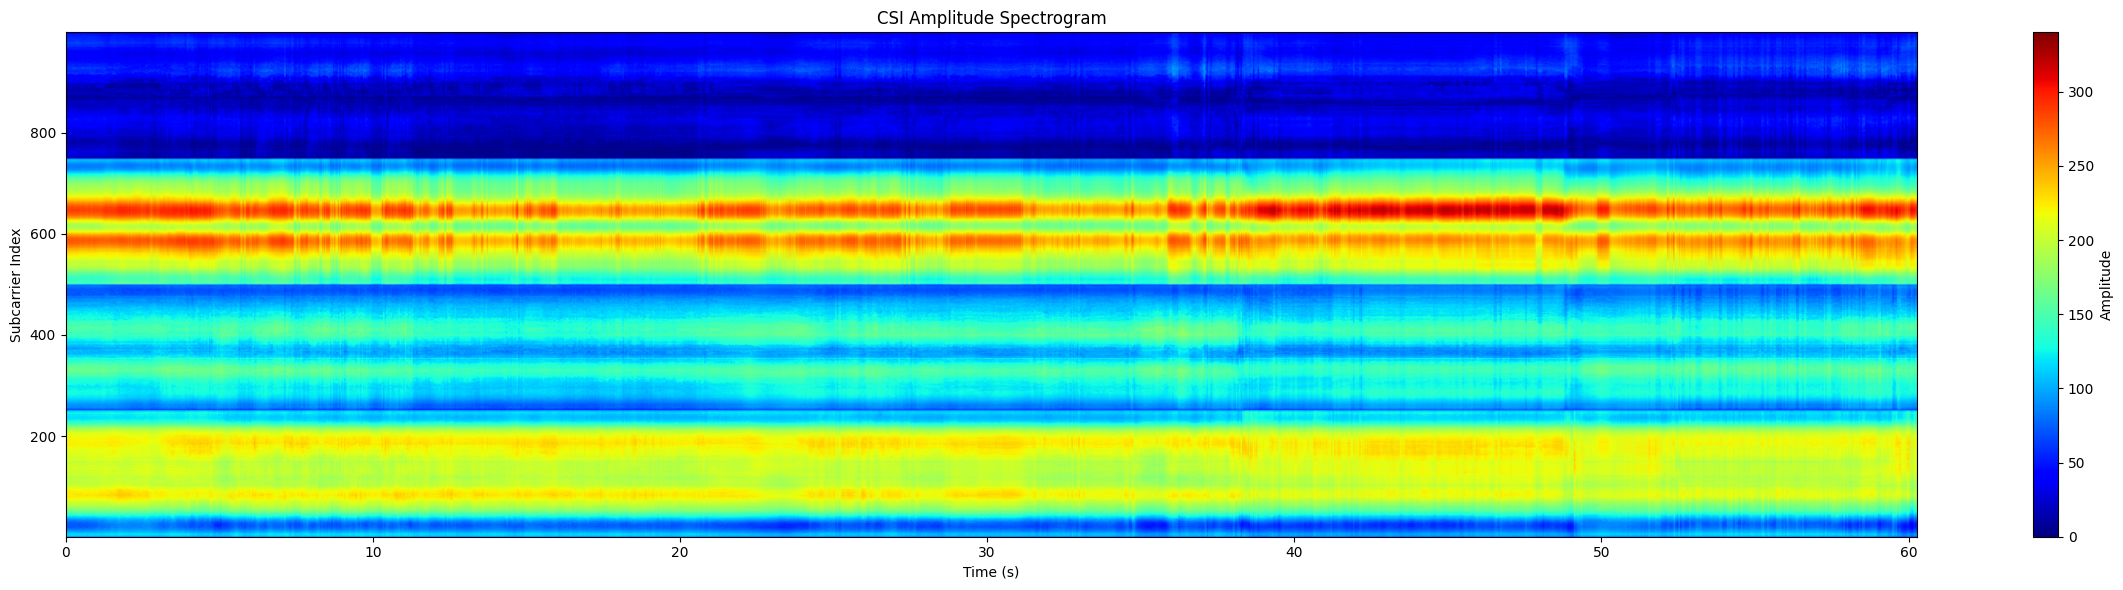

In [20]:
# ── Preview: full spectrogram of the entire recording ─────────────────────────
plot_csi_spectrogram(amp_matrix)

# ── Generate sliding-window spectrograms (model inputs) ───────────────────────
# Each PNG = 2-second window, one per second, saved as 224×224 pixels.
# 'second' in the metadata aligns with the 'second' column in the label CSVs.
# meta = save_sliding_window_spectrograms(
#     amp_df      = amp_matrix,
#     output_dir  = f"model_data/{filename.split('/')[0]}",
#     window_sec  = 2.0,
#     stride_sec  = 1.0,
#     img_size    = (224, 224),
#     cmap        = 'jet',
#     video_name  = Path(filename).name,
# )

# # Inspect the metadata table
# meta_df = pd.DataFrame(meta)
# display(meta_df)